| 방법         | 기준      | 안정성  |
| ---------- | ------- | ---- |
| Elbow      | inertia | 보통   |
| Silhouette | 거리 구조   | 높음 ⭐ |


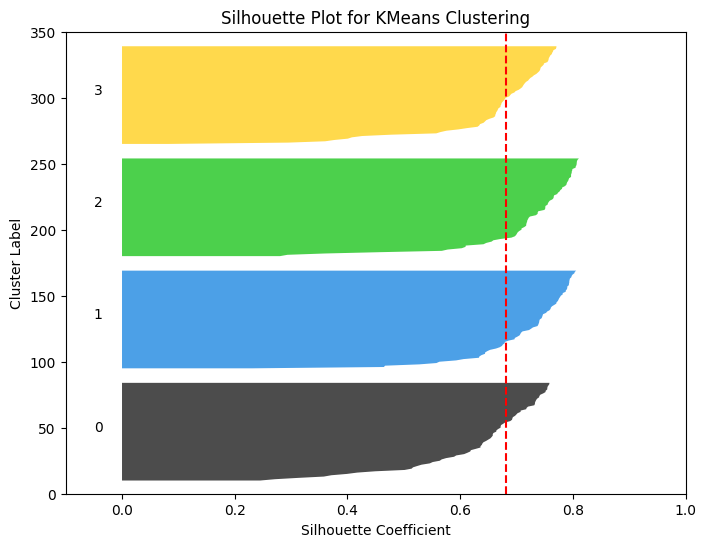

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1️⃣ 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K 설정
k = 4
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(X)

# 3️⃣ 전체 silhouette score
sil_avg = silhouette_score(X, labels)

# 4️⃣ 각 샘플 silhouette 값
sample_silhouette_values = silhouette_samples(X, labels)

# 5️⃣ 시각화 설정
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(8, 6)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X) + (k + 1) * 10])

y_lower = 10

# 6️⃣ 클러스터별 plot
for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k)

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        alpha=0.7
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

# 7️⃣ 평균선
ax1.axvline(x=sil_avg, color="red", linestyle="--")

ax1.set_title("Silhouette Plot for KMeans Clustering")
ax1.set_xlabel("Silhouette Coefficient")
ax1.set_ylabel("Cluster Label")

plt.show()

# 실루엣 계수
![alt text](image.png)

# 실구엣 계수 해석 방법

# 📊 Silhouette Plot 해석 (KMeans 결과 기준)

---

## 🧠 1️⃣ 전체 구조 이해

이 그래프는 3가지를 동시에 보여준다:

```text id="structure"
1. 각 클러스터 내부 품질 (색 블록)
2. 각 데이터의 품질 점수 (x축)
3. 전체 평균 품질 (빨간 점선)

🔥 2️⃣ x축 (Silhouette Coefficient)
-0.1 ~ 1
✔ 의미
값	해석
1	완벽하게 분리됨 ⭐
0.5 ~ 1	잘 나뉨 👍
0 ~ 0.5	애매
0	경계
< 0	잘못 분류 ❌
💡 핵심 해석
막대가 오른쪽으로 길수록 좋은 클러스터
🔥 3️⃣ 색깔 블록 (Cluster 0, 1, 2, 3)
각 색 = 하나의 클러스터 (총 4개)
✔ 의미
각 클러스터 내부 데이터들의 품질 분포
✔ 좋은 클러스터
- 대부분 오른쪽 (0.5 이상)
- 길게 퍼짐
❌ 나쁜 클러스터
- 0 근처 많음
- 왼쪽(-) 존재
🔥 4️⃣ 빨간 점선 (전체 평균)
ax1.axvline(x=sil_avg, color="red", linestyle="--")
✔ 의미
전체 Silhouette Score 평균
✔ 해석
대부분이 빨간선 오른쪽 → 좋은 clustering 👍
대부분이 왼쪽 → 클러스터링 실패 ❌
🧠 5️⃣ y축 (Cluster Label)
Cluster 0 / 1 / 2 / 3
✔ 의미
각 클러스터별 데이터 묶음
💥 전체 그림 이해
Cluster 0  ██████████→ (좋음)
Cluster 1  ███████→
Cluster 2  ███→ (애매)
Cluster 3  ██← (나쁨)
              |
         평균선 (red)
🧠 핵심 해석 포인트 3개
✔ 1️⃣ 오른쪽 길이
길수록 좋다 (클러스터 잘 됨)
✔ 2️⃣ 왼쪽 (-값)
잘못 분류된 데이터 존재
✔ 3️⃣ 빨간선 기준
전체 품질 기준선
🔥 이 그래프의 결론
K=4일 때:
→ 대부분 잘 나뉘어 있음 (성공적인 clustering)
→ 일부 애매한 데이터 존재 가능
🚀 한 줄 핵심

👉 "Silhouette Plot은 각 데이터가 자기 클러스터에 얼마나 잘 맞는지를 시각적으로 보여주는 품질 진단 그래프다"
```